# EDA — College / pre-NBA features (Deliverable 2)

Explores **Sports Reference college** blocks merged on `model_base_player_season.csv` (`cbb_*` columns, recruiting fields). Each player's `cbb_*` values come from their **final (most recent) NCAA season** (not the SR **Career** row); those repeat on every NBA season row. We **dedupe NBA seasons** then take **one row per `nba_player_id`** for plots. Companion to `02_eda_outcomes.ipynb`.

We join **`player_career_summary_v1.csv`** for tiers, entry cohort, and `success_composite_v1`. The **EDA slice** below is **tier D ∩ entry cohort ∩ college id ∩ non-null composite** (used for plots and correlations among **college** columns). **Deliverable 3** (`src/models/training_data.py`) uses the **same filters** plus **complete case on `cbb_advanced_BPM`** and adds **`nba_debut_age`** and **rookie NBA position dummies** — so the modeling row count is **smaller** than the EDA slice when some players lack college BPM.

**Recruiting** (`recruiting_rank` / `recruiting_year`) stays in this notebook for **EDA only** — Deliverable 3 models do **not** use it (sparse). The notebook adds the **same** **NBA demographics** as supervised modeling (**`nba_debut_age`**, rookie-**`Pos`** dummies) via `attach_nba_demographics_for_eda`, so correlation plots align with **age/pos + college advanced** (plus recruiting and optional totals columns in the heatmap/missingness lists).

Figures save to `progress/figures/` (`eda_cbb_*.png`).

In [1]:
from pathlib import Path
import importlib
import sys

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import display

_cands = [Path(".").resolve(), Path("..").resolve(), Path.cwd()]
ROOT = next(p for p in _cands if (p / "data" / "processed" / "model_base_player_season.csv").exists())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

_co = importlib.import_module("src.analysis.career_outcomes")
importlib.reload(_co)
build_player_career_summary = _co.build_player_career_summary
dedupe_nba_player_season = _co.dedupe_nba_player_season

_td = importlib.import_module("src.models.training_data")
importlib.reload(_td)
attach_nba_demographics_for_eda = _td.attach_nba_demographics_for_eda

PROC = ROOT / "data" / "processed"
FIG = ROOT / "progress" / "figures"
FIG.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid", context="notebook")

mb = pd.read_csv(PROC / "model_base_player_season.csv")
ded = dedupe_nba_player_season(mb)
players = ded.drop_duplicates(subset=["nba_player_id"], keep="first").copy()

summ = pd.read_csv(PROC / "player_career_summary_v1.csv")
base = players.merge(summ, on="nba_player_id", how="left", validate="one_to_one")

base["has_college_id"] = base["college_player_id"].notna() & (base["college_player_id"].astype(str).str.len() > 0)
mod = (
    base["nba_run_tier"].eq("D")
    & base["entry_cohort"]
    & base["has_college_id"]
    & base["success_composite_v1"].notna()
).fillna(False)
m = base.loc[mod].copy()
m = attach_nba_demographics_for_eda(m, mb)

print("Unique NBA players (after season dedupe):", base["nba_player_id"].nunique())
print("With college_player_id:", int(base["has_college_id"].sum()))
print("EDA slice (D ∩ cohort ∩ college ∩ composite):", len(m))
print(
    "Deliverable 3 modeling rows (add BPM complete-case; see build_supervised_frame):",
    int(m["cbb_advanced_BPM"].notna().sum()),
)

Unique NBA players (after season dedupe): 1812
With college_player_id: 1528
EDA slice (D ∩ cohort ∩ college ∩ composite): 611
Deliverable 3 modeling rows (add BPM complete-case; see build_supervised_frame): 595


In [2]:
from src.models.training_data import CBB_ADVANCED_FEATURE_COLS, DEMOGRAPHIC_FEATURE_COLS

# Recruiting + extra totals: EDA only (Deliverable 3 does not use these in the model).
RECRUIT_COLS = ["recruiting_rank", "recruiting_year"]
TOTALS_EXTRA = ["cbb_totals_G", "cbb_totals_MP"]

FEATURE_COLS = (
    RECRUIT_COLS
    + DEMOGRAPHIC_FEATURE_COLS
    + list(CBB_ADVANCED_FEATURE_COLS)
    + TOTALS_EXTRA
)

existing = [c for c in FEATURE_COLS if c in m.columns]
miss_pct = (m[existing].isna().mean() * 100).sort_values(ascending=False)
print("Missing % of columns (EDA slice: tier D ∩ cohort ∩ college ∩ composite):")
display(miss_pct.to_frame("pct_missing"))

num_for_desc = [c for c in existing if c not in ("recruiting_year",)]
desc = m[num_for_desc].describe(percentiles=[0.25, 0.5, 0.75]).T
print("Five-number style summary (numeric):")
display(desc.round(3))

if "recruiting_year" in m.columns:
    ry = m["recruiting_year"].dropna()
    print(
        "recruiting_year: n=%d, min=%s, max=%s"
        % (len(ry), ry.min(), ry.max())
    )

Missing % of columns (EDA slice: tier D ∩ cohort ∩ college ∩ composite):


,pct_missing
recruiting_rank,41.080196
recruiting_year,41.080196
cbb_advanced_BPM,2.618658
cbb_advanced_OBPM,2.618658
cbb_advanced_DBPM,2.618658
cbb_advanced_PER,1.472995
cbb_advanced_STLpct,1.472995
cbb_advanced_ORBpct,1.472995
cbb_advanced_DRBpct,1.472995
cbb_advanced_TRBpct,0.327332


Five-number style summary (numeric):


,count,mean,std,min,25%,50%,75%,max
recruiting_rank,360.0,33.139,28.127,1.000,10.000,24.500,51.000,100.000
nba_debut_age,611.0,21.591,1.824,19.000,20.000,22.000,23.000,29.000
pos_is_SG,611.0,0.282,0.450,0.000,0.000,0.000,1.000,1.000
pos_is_SF,611.0,0.185,0.389,0.000,0.000,0.000,0.000,1.000
pos_is_PF,611.0,0.208,0.406,0.000,0.000,0.000,0.000,1.000
pos_is_C,611.0,0.126,0.332,0.000,0.000,0.000,0.000,1.000
cbb_advanced_PER,602.0,23.057,4.917,9.400,19.900,22.350,25.900,52.700
cbb_advanced_BPM,595.0,7.971,3.006,-3.000,6.200,8.000,9.850,20.100
cbb_advanced_OBPM,595.0,5.212,2.366,-2.700,3.600,5.100,6.700,13.400
cbb_advanced_DBPM,595.0,2.757,1.683,-2.200,1.600,2.600,3.800,9.200


recruiting_year: n=360, min=2004.0, max=2021.0


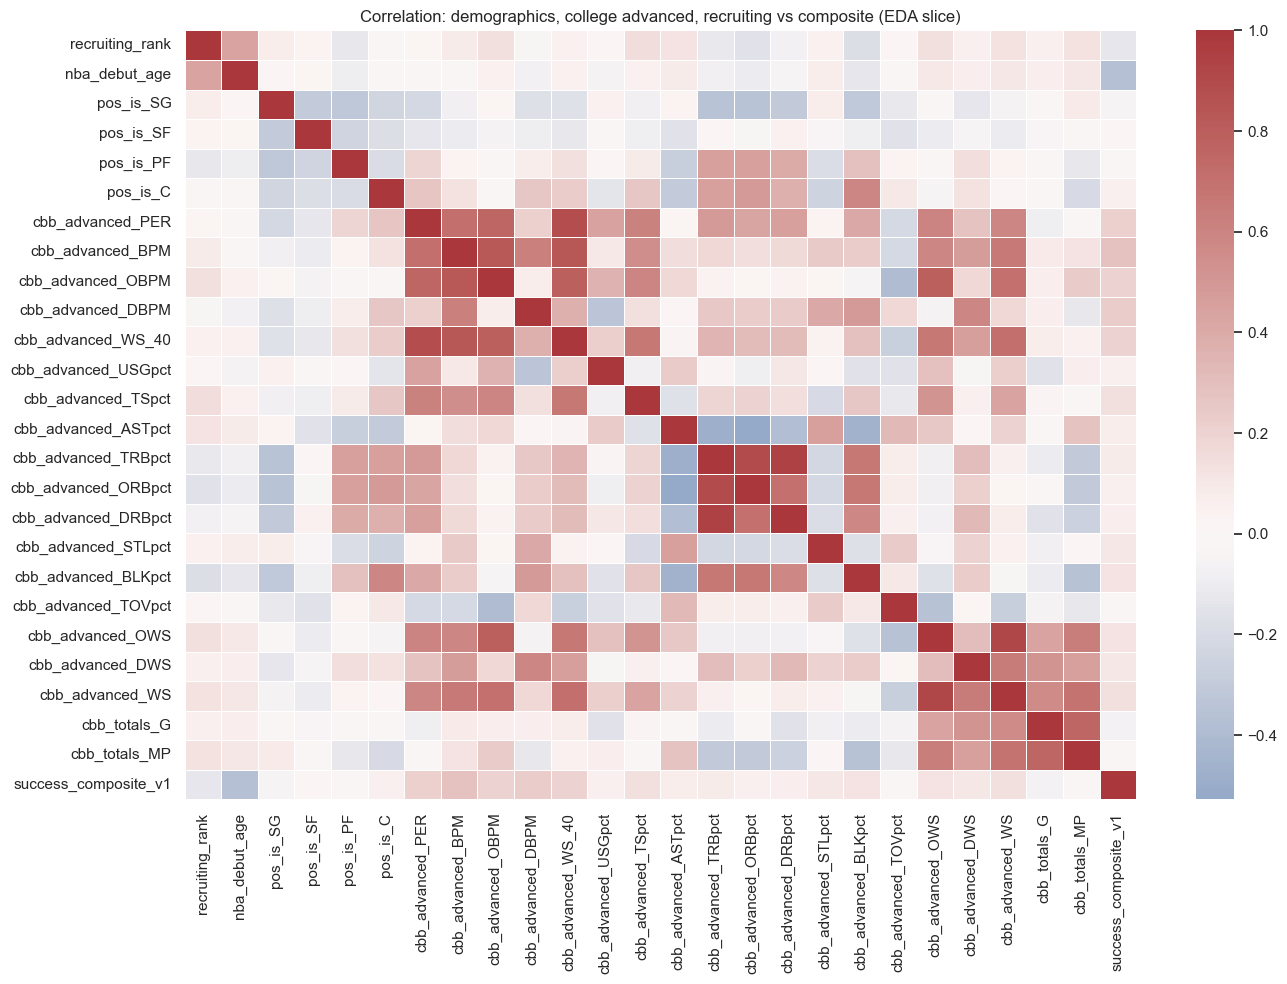

In [3]:
corr_cols = [c for c in FEATURE_COLS if c in m.columns and c != "recruiting_year"]
corr_cols = corr_cols + ["success_composite_v1"]
corr_mat = m[corr_cols].corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(14, 10))
sns.heatmap(corr_mat, ax=ax, cmap="vlag", center=0, annot=False, linewidths=0.5)
ax.set_title("Correlation: demographics, college advanced, recruiting vs composite (EDA slice)")
fig.tight_layout()
fig.savefig(FIG / "eda_cbb_feature_correlation.png", dpi=150)
plt.show()

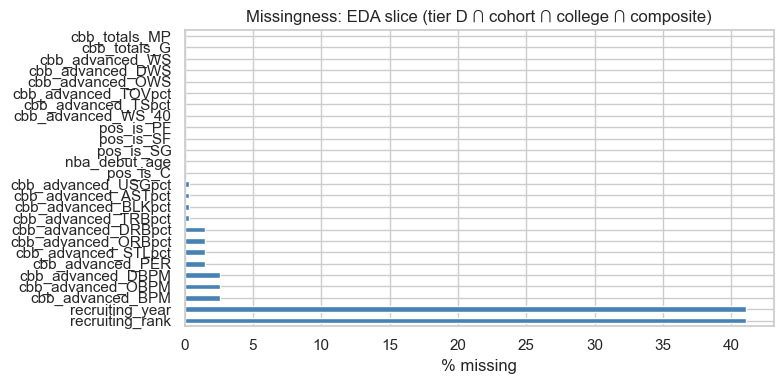

In [4]:
fig, ax = plt.subplots(figsize=(8, 4))
miss_pct.plot(kind="barh", ax=ax, color="steelblue")
ax.set_xlabel("% missing")
ax.set_title("Missingness: EDA slice (tier D ∩ cohort ∩ college ∩ composite)")
fig.tight_layout()
fig.savefig(FIG / "eda_cbb_missingness.png", dpi=150)
plt.show()

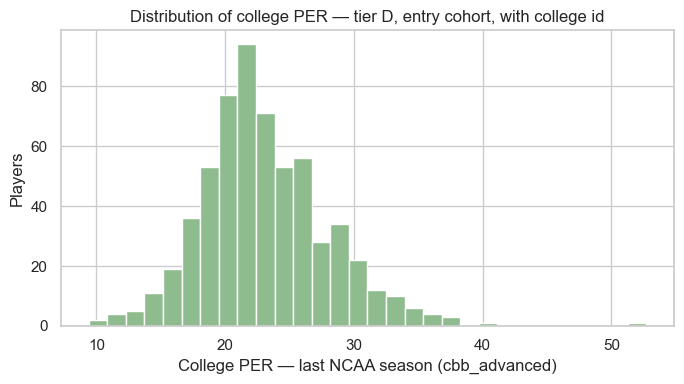

In [5]:
per = m["cbb_advanced_PER"].dropna()
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(per, bins=30, color="darkseagreen", edgecolor="white")
ax.set_xlabel("College PER — last NCAA season (cbb_advanced)")
ax.set_ylabel("Players")
ax.set_title("Distribution of college PER — tier D, entry cohort, with college id")
fig.tight_layout()
fig.savefig(FIG / "eda_cbb_per_distribution.png", dpi=150)
plt.show()

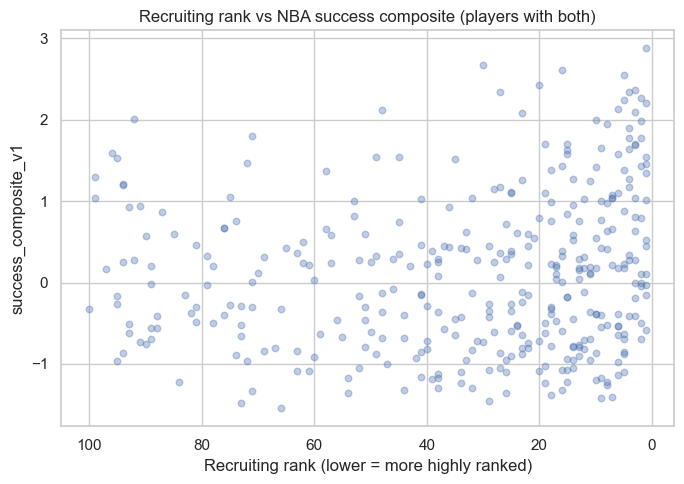

n with both recruiting_rank and composite: 360


In [6]:
sub = m.dropna(subset=["recruiting_rank", "success_composite_v1"]).copy()
fig, ax = plt.subplots(figsize=(7, 5))
if len(sub) > 5:
    ax.scatter(sub["recruiting_rank"], sub["success_composite_v1"], alpha=0.35, s=22)
    ax.invert_xaxis()
    ax.set_xlabel("Recruiting rank (lower = more highly ranked)")
    ax.set_ylabel("success_composite_v1")
    ax.set_title("Recruiting rank vs NBA success composite (players with both)")
else:
    ax.text(0.5, 0.5, "Not enough joint non-null recruiting_rank + composite", ha="center")
fig.tight_layout()
fig.savefig(FIG / "eda_cbb_recruit_vs_composite.png", dpi=150)
plt.show()
print("n with both recruiting_rank and composite:", len(sub))